# Figure 1.1.1 — Baseline Drift

Generates a four-panel illustration of the **physical reality** of representational drift in the RNN model — weight and firing-rate shifts across simulated days — before abstracting them into distance or similarity metrics.

The model is a rate-based RNN (50 neurons) driven by structured intrinsic excitability fluctuations and synaptic volatility noise. A **single-context** input stimulates the full population uniformly; any representational change therefore arises from internal network dynamics, not from changing stimulus statistics.

> **Caching:** simulation output is saved to `data/` on first run and reloaded automatically. Re-run with `force=True` in `get_or_run(...)` to regenerate.


In [16]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, os.getcwd())
from model import ModelParams, get_or_run, extract_arrays, compute_input_trace
from plot_style import apply_style, COLORS, CMAPS, FIG_SIZES, FONT, LW

## Parameters

Adjust any value below. The simulation **re-runs automatically** when parameters differ
from the cached run, and always overwrites the single saved result for this figure.

| Group | Parameter | Default | Description |
|-------|-----------|---------|-------------|
| Drift | `E` | 1.5 | Peak excitability amplitude per neuron group |
| Drift | `vol_std` | 0.02 | Synaptic volatility noise std dev σ |
| Network τ | `taur` | 50 ms | Firing-rate decay time constant |
| Network τ | `tauw` | 1000 ms | Hebbian weight potentiation rate |
| Network τ | `decay` | 1000 ms | Synaptic weight passive decay |
| Readout τ | `tau_out_plus` | 200 ms | Readout potentiation time constant |
| Readout τ | `tau_out_minus` | 1000 ms | Readout weight decay time constant |
| Stimulus | `IN` | 15 | Input pulse amplitude |
| Stimulus | `Nevent` | 4 | Number of simulated days |
| Other | `seed` | 0 | Random seed |

In [17]:
# ── Drift mechanisms ──────────────────────────────────────────────────────────
E         = 2   # excitability amplitude      (try: 0.5, 1.0, 1.5, 2.0)
vol_std   = 0.02   # synaptic volatility σ        (try: 0.005, 0.02, 0.06, 0.1)

# ── Network time constants ────────────────────────────────────────────────────
taur      = 50.0   # firing-rate decay (ms)
tauw      = 1000.0 # Hebbian weight potentiation (ms)
decay     = 1000.0 # synaptic weight passive decay (ms)

# ── Readout time constants ────────────────────────────────────────────────────
tau_out_plus  = 200.0  # readout potentiation (ms)
tau_out_minus = 1000.0 # readout weight decay (ms)

# ── Stimulus & experiment ─────────────────────────────────────────────────────
IN        = 15.0   # input pulse amplitude
Nevent    = 4      # number of simulated days
seed      = 0      # random seed
# ─────────────────────────────────────────────────────────────────────────────

NOTEBOOK_DIR = os.path.abspath("")
FIGURES_DIR  = os.path.join(NOTEBOOK_DIR, "saved_figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

p = ModelParams(
    E=E, vol_std=vol_std,
    taur=taur, tauw=tauw, decay=decay,
    tau_out_plus=tau_out_plus, tau_out_minus=tau_out_minus,
    IN=IN, Nevent=Nevent, seed=seed,
)
print(f"E={p.E}  vol_std={p.vol_std}  taur={p.taur}  tauw={p.tauw}  decay={p.decay}")
print(f"tau_out+={p.tau_out_plus}  tau_out-={p.tau_out_minus}  IN={p.IN}  Nevent={p.Nevent}  seed={p.seed}")

E=2  vol_std=0.02  taur=50.0  tauw=1000.0  decay=1000.0
tau_out+=200.0  tau_out-=1000.0  IN=15.0  Nevent=4  seed=0


In [18]:
DATA_NAME = "fig1_1_1_baseline"

result = get_or_run(p, DATA_NAME)
# Auto-rerun if cached params differ from current params
if result["params"] != p:
    print("Parameters changed — re-running simulation...")
    result = get_or_run(p, DATA_NAME, force=True)

arrays   = extract_arrays(result)
r        = arrays["r"]       # (N, nstep)  — population firing rates
W_flat   = arrays["W"]       # (N², nstep) — recurrent weights, flattened
Emat     = result["Emat"]    # (N, nstep)  — pre-computed excitability matrix
day_ts   = result["day_timesteps"]
seq      = result["seq"]
N, nstep = p.N, p.nstep
t_axis   = np.arange(nstep) * p.dt

Running simulation (seed=0, E=2, vol_std=0.02) ...


## Figure panels

| Panel | Content |
|-------|---------|
| **A** | **Excitability matrix** *E(t)*: structured neuron-group × time-period pattern. Each group of 10 neurons receives a transient excitability boost during a different day-period (an offset-diagonal block structure), plus a neuron-specific random baseline. This is the primary driver of drift. |
| **B** | **Input stimulus** *I*_ext(*t*): single-context pulse train delivered identically to all 50 neurons. The stimulus is identical every day — representational changes arise solely from internal dynamics. |
| **C** | **Recurrent weight matrices** *W* snapshotted at the end of each day. Spatial redistribution of synaptic strengths reflects the combined action of Hebbian potentiation and synaptic volatility noise. |
| **D** | **Population firing rates** (heatmap, cividis) across the full simulation. Neuron index 0 is at the top. Shifts in the active sub-population from day to day constitute the representational drift quantified in later figures. White dashed lines mark day transitions. |


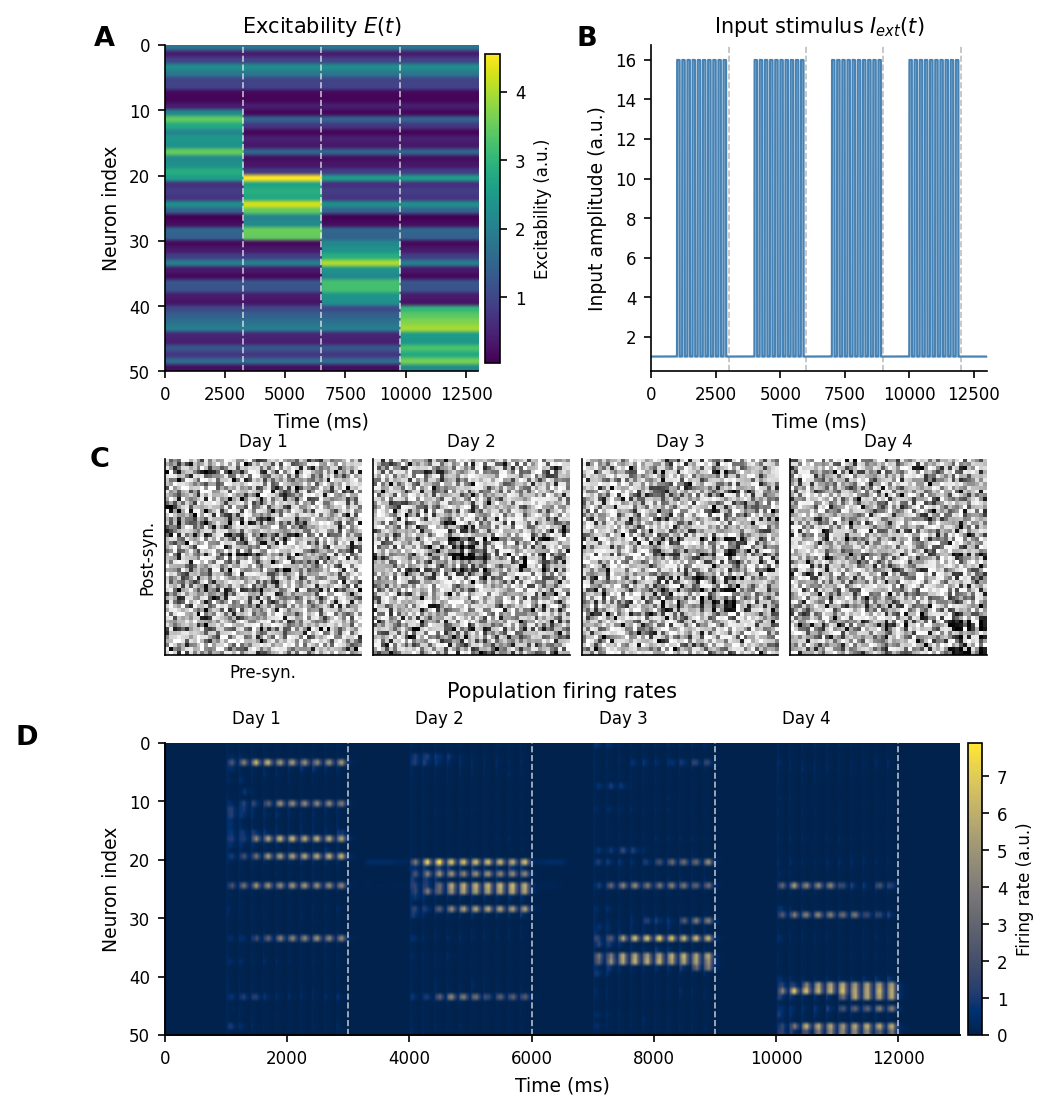

In [19]:
apply_style()

fig = plt.figure(figsize=FIG_SIZES["full_a4"])

gs_AB = gridspec.GridSpec(1, 2, figure=fig,
                          left=0.10, right=0.97, top=0.96, bottom=0.67, wspace=0.45)
gs_C  = gridspec.GridSpec(1, p.Nevent, figure=fig,
                          left=0.10, right=0.97, top=0.61, bottom=0.40, wspace=0.06)
gs_D  = gridspec.GridSpec(1, 1, figure=fig,
                          left=0.10, right=0.97, top=0.34, bottom=0.08)

ax_A = fig.add_subplot(gs_AB[0])
ax_B = fig.add_subplot(gs_AB[1])
ax_C = [fig.add_subplot(gs_C[d]) for d in range(p.Nevent)]
ax_D = fig.add_subplot(gs_D[0])


def _label(ax, txt, x=-0.16, y=1.06):
    ax.text(x, y, txt, transform=ax.transAxes,
            fontsize=FONT["panel_label"], fontweight="bold", va="top", ha="right")

def _day_lines(ax, col=COLORS["day_line"], alpha=0.7):
    for ts in day_ts[1:]:
        ax.axvline(ts, color=col, lw=LW["day_line"], ls="--", alpha=alpha)


# ── Panel A — Excitability matrix ────────────────────────────────────────────
im_A = ax_A.imshow(Emat, aspect="auto", origin="lower",
                   extent=[0, nstep, 0, N], cmap=CMAPS["excitability"])
ax_A.invert_yaxis()
nt_emat = p.nstep // p.E_time_divisions
for j in range(1, p.E_time_divisions):
    ax_A.axvline(j * nt_emat, color=COLORS["day_line"], lw=LW["day_line"], ls="--", alpha=0.7)
plt.colorbar(im_A, ax=ax_A, pad=0.02, fraction=0.046).set_label(
    "Excitability (a.u.)", fontsize=FONT["colorbar"])
ax_A.set_xlabel("Time (ms)")
ax_A.set_ylabel("Neuron index")
ax_A.set_title("Excitability $E(t)$")
ax_A.set_xlim(0, nstep)
_label(ax_A, "A")

# ── Panel B — Input stimulus ─────────────────────────────────────────────────
inp = compute_input_trace(t_axis, seq, p.IN, N)
ax_B.plot(t_axis, inp, color=COLORS["input"], lw=LW["trace"])
ax_B.fill_between(t_axis, inp.min(), inp, alpha=0.25, color=COLORS["input"])
_day_lines(ax_B, col=COLORS["day_line_light"], alpha=0.5)
ax_B.set_xlabel("Time (ms)")
ax_B.set_ylabel("Input amplitude (a.u.)")
ax_B.set_title("Input stimulus $I_{ext}(t)$")
ax_B.set_xlim(0, nstep)
_label(ax_B, "B")

# ── Panel C — Weight matrices at end of each day ─────────────────────────────
_label(ax_C[0], "C", x=-0.28)
for d, ax in enumerate(ax_C):
    t_end = day_ts[d + 1] - 1
    W_day = W_flat[:, t_end].reshape(N, N)
    ax.imshow(W_day, aspect="equal", origin="lower",
              cmap=CMAPS["weights"], vmin=0, vmax=1, interpolation="nearest")
    ax.invert_yaxis()
    ax.set_title(f"Day {d + 1}", fontsize=FONT["tick"])
    ax.set_xticks([])
    ax.set_yticks([])
    if d == 0:
        ax.set_ylabel("Post-syn.", fontsize=FONT["annotation"])
        ax.set_xlabel("Pre-syn.", fontsize=FONT["annotation"])

# ── Panel D — Firing rates heatmap ───────────────────────────────────────────
im_D = ax_D.imshow(np.maximum(0, r), aspect="auto", origin="lower",
                   extent=[0, nstep, 0, N], cmap=CMAPS["firing_rate"])
ax_D.invert_yaxis()
_day_lines(ax_D)
plt.colorbar(im_D, ax=ax_D, pad=0.01, fraction=0.023).set_label(
    "Firing rate (a.u.)", fontsize=FONT["colorbar"])
ax_D.set_xlabel("Time (ms)")
ax_D.set_ylabel("Neuron index")
ax_D.set_title("Population firing rates")
ax_D.set_xlim(0, nstep)
_label(ax_D, "D")

# Secondary x-axis on Panel D showing day numbers
day_mid = [(day_ts[d] + day_ts[d + 1]) / 2 for d in range(p.Nevent)]
ax_D2 = ax_D.twiny()
ax_D2.set_xlim(ax_D.get_xlim())
ax_D2.set_xticks(day_mid)
ax_D2.set_xticklabels([f"Day {d + 1}" for d in range(p.Nevent)],
                      fontsize=FONT["annotation"])
ax_D2.tick_params(top=False, labeltop=True)
ax_D2.spines["top"].set_visible(False)

plt.show()

In [20]:
out_path = os.path.join(FIGURES_DIR, "fig1_1_baseline_drift.pdf")
plt.tight_layout()
fig.savefig(out_path, dpi=300)
print(f"Figure saved -> {out_path}")

Figure saved -> c:\Users\sctcl\Thesis_Exct&Vol_Model\results_figures\saved_figures\fig1_1_baseline_drift.pdf


<Figure size 960x720 with 0 Axes>